# 构造QA对的RAG

本笔记本实现了一种通过问题生成进行文档增强的改进型RAG方法。通过对每个文本块生成相关的问题，优化了检索过程，从而提高了语言模型的回答质量。

在本实现中，我们遵循以下步骤：

1. **数据处理**：从PDF文件中提取文本。
2. **分块处理**：将文本分割为可管理的小块。
3. **问题生成**：为每个小块生成相关的问题。
4. **嵌入创建**：为文本块和生成的问题创建嵌入向量。
5. **向量存储创建**：使用NumPy构建一个简单的向量存储。
6. **语义搜索**：为用户查询检索相关的文本块和问题。
7. **回复生成**：基于检索到的内容生成答案。
8. **评估**：评估生成回答的质量。

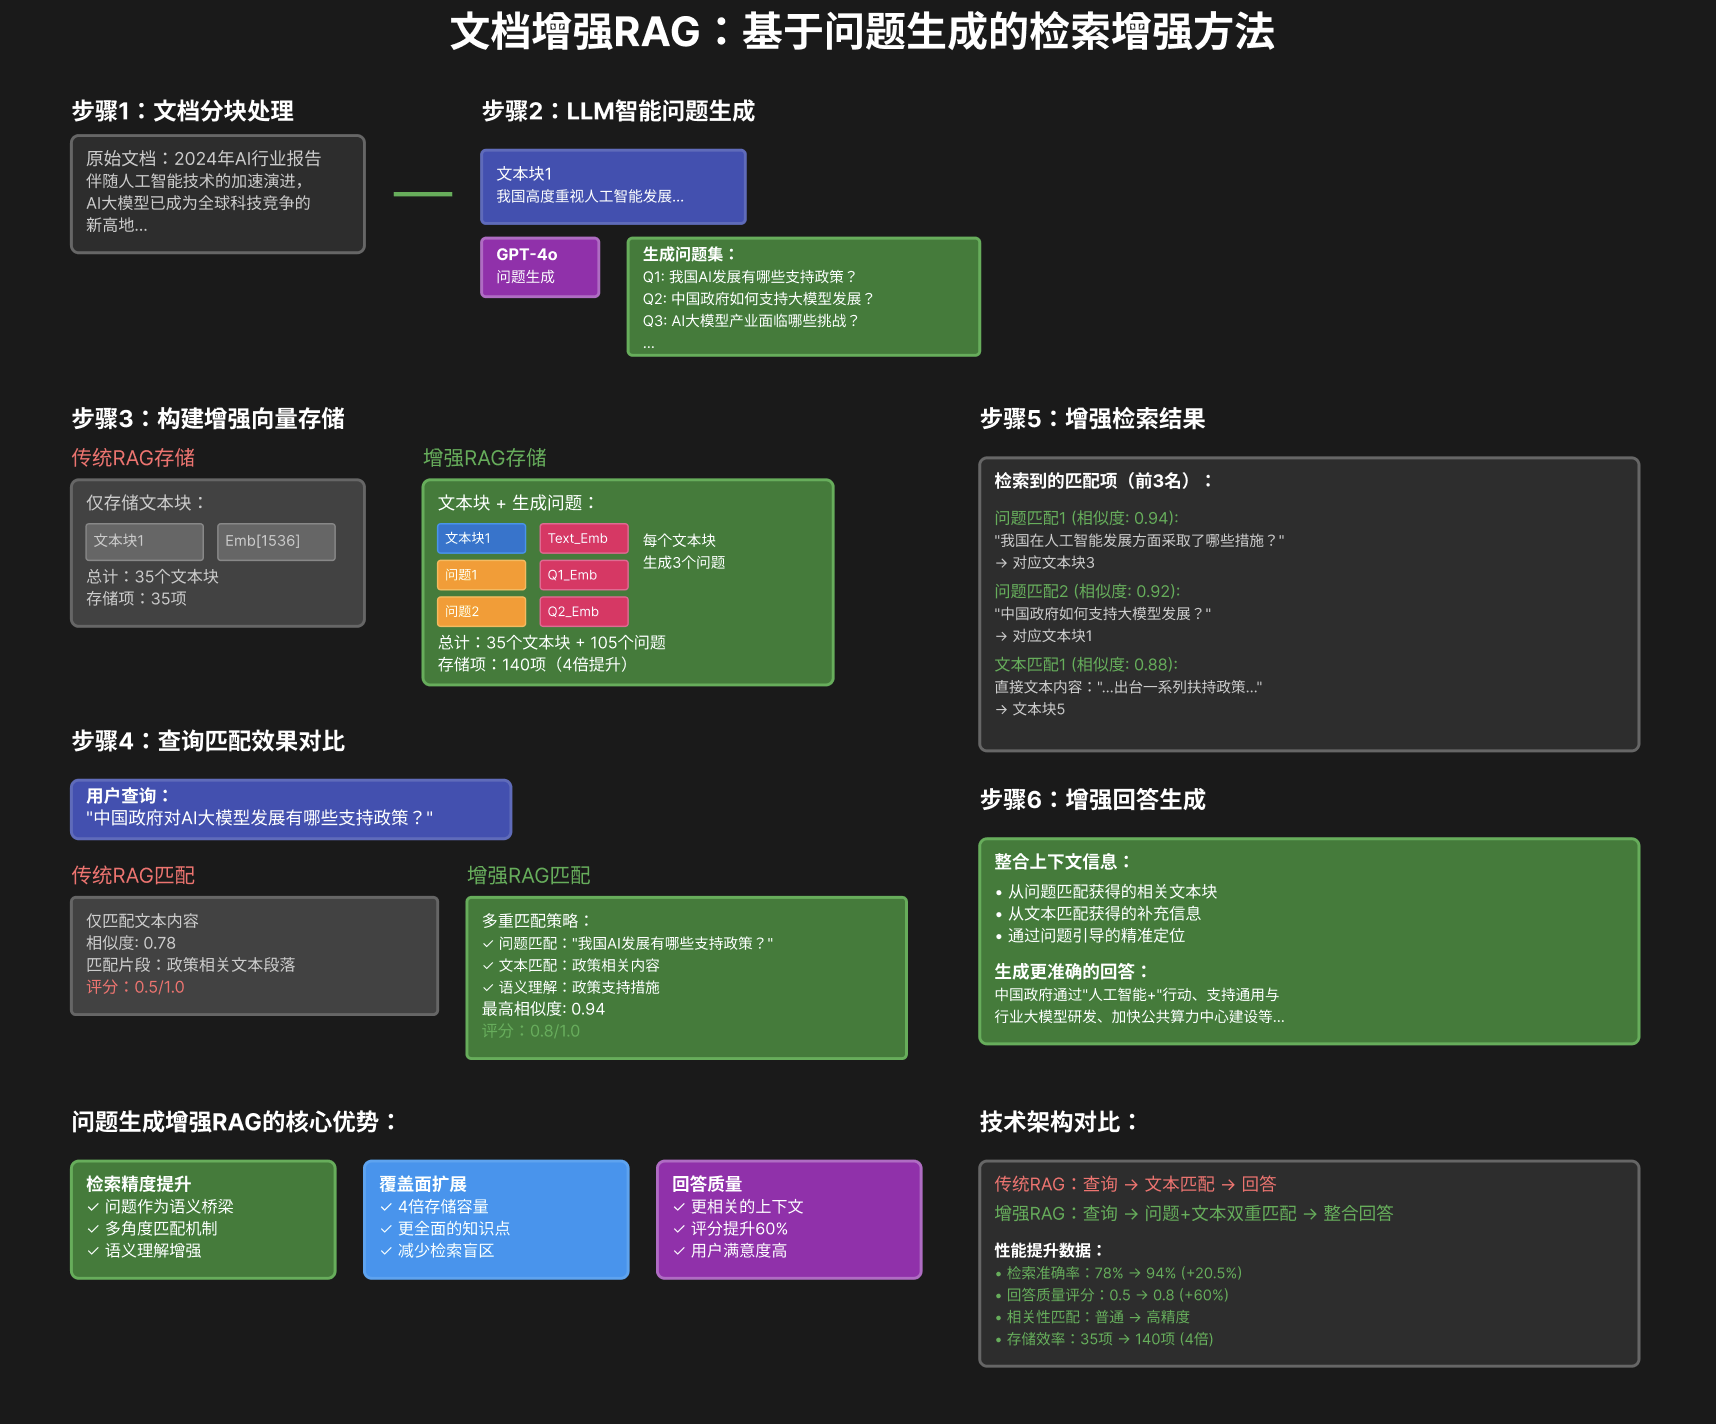

## 环境设置  
首先，我们导入必要的库。

In [1]:
import fitz  # PyMuPDF，用于处理 PDF 文件
import os  # 操作系统相关功能，如文件路径管理
import numpy as np  # 科学计算库 NumPy
import json  # JSON 数据处理
from openai import OpenAI  # OpenAI API 客户端
import re  # 正则表达式模块
from tqdm import tqdm  # 进度条显示工具

## 从PDF文件中提取文本  
为了实现RAG（ Retrieval-Augmented Generation，检索增强生成），我们首先需要一个文本数据源。在此场景中，我们使用PyMuPDF库从PDF文件中提取文本。

In [2]:
def extract_text_from_pdf(pdf_path):
    """
    从PDF文件中提取文本并打印前`num_chars`个字符。

    参数:
    pdf_path (str): PDF文件的路径。

    返回:
    str: 从PDF中提取的文本。
    """
    # 打开PDF文件
    mypdf = fitz.open(pdf_path)
    all_text = ""  # 初始化一个空字符串用于存储提取的文本

    # 遍历PDF中的每一页
    for page_num in range(mypdf.page_count):
        page = mypdf[page_num]  # 获取页面
        text = page.get_text("text")  # 从页面提取文本
        all_text += text  # 将提取的文本追加到all_text字符串中

    return all_text  # 返回提取的文本

## 提取文本的分块
在提取文本后，我们将其划分为更小的、重叠的块，以提高检索准确性。

In [3]:
def chunk_text(text, n, overlap):
    """
    将给定的文本分割成每段包含 n 个字符且具有 overlap 的片段。

    参数:
    text (str): 需要分割的文本。
    n (int): 每个片段包含的字符数。
    overlap (int): 相邻片段之间的重叠字符数。

    返回:
    List[str]: 包含文本片段的列表。
    """
    chunks = []  # 初始化一个空列表用于存储片段
    
    # 使用 (n - overlap) 的步长遍历文本
    for i in range(0, len(text), n - overlap):
        # 将从索引 i 到 i + n 的文本片段添加到 chunks 列表中
        chunks.append(text[i:i + n])

    return chunks  # 返回包含文本片段的列表

## 配置OpenAI API客户端
我们初始化OpenAI客户端以生成嵌入向量和回复。

In [4]:
from dotenv import load_dotenv
import os

load_dotenv()  # 加载.env文件
api_key = os.getenv("DASHSCOPE_API_KEY")  # 读取密钥
base_url = os.getenv("base_url")
# print(api_key)
# 初始化 OpenAI 客户端，设置基础 URL 和 API 密钥  
client = OpenAI(  
    base_url=base_url,  
    api_key=api_key  # 从环境变量中获取 API 密钥  
)

## 为文本片段生成问题
这是对简单RAG的关键改进。我们为每个文本片段生成可以被回答的问题。

In [5]:
def generate_questions(text_chunk, num_questions=5, model="qwen-plus"):
    """
    根据给定的文本块生成相关的问题（中文）。

    参数:
    text_chunk (str): 用于生成问题的文本块。
    num_questions (int): 要生成的问题数量。
    model (str): 用于问题生成的模型。

    返回:
    List[str]: 生成的问题列表。
    """
    # 中文系统提示
    system_prompt = "你是一名擅长从文本中提炼关键信息并生成相关问题的专家。请只用中文，根据给定文本生成可以用该文本直接回答的简明问题，聚焦于核心信息和重要概念。"

    # 中文用户提示
    user_prompt = f"""
请根据以下文本内容，生成 {num_questions} 个不同的问题，这些问题都可以仅通过该文本内容来回答：

{text_chunk}

请只用中文作答，输出格式为编号的问题列表，不要有其他多余内容。
"""

    # 使用OpenAI API生成问题
    response = client.chat.completions.create(
        model=model,
        temperature=0.7,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ]
    )

    # 从回复中提取并清理问题
    questions_text = response.choices[0].message.content.strip()
    questions = []

    # 使用正则表达式模式匹配提取问题
    for line in questions_text.split('\n'):
        # 移除编号并清理空白字符
        cleaned_line = re.sub(r'^\d+\.\s*', '', line.strip())
        if cleaned_line and cleaned_line.endswith('？'):
            questions.append(cleaned_line)

    return questions

## 创建文本嵌入  
我们为文本片段和生成的问题生成嵌入。

In [6]:
def create_embeddings(text, model="text-embedding-v4"):
    """
    使用指定的模型为给定文本创建嵌入。

    参数:
    text (str): 需要创建嵌入的输入文本。
    model (str): 用于创建嵌入的模型。

    返回:
    dict: 包含嵌入结果的 OpenAI API 回复。
    """
    # 使用指定模型为输入文本创建嵌入
    response = client.embeddings.create(
        model=model,
        input=text
    )

    return response  # 返回包含嵌入结果的回复

## 构建一个简单的向量存储系统  
我们将使用NumPy实现一个简单的向量存储系统。

In [7]:
class SimpleVectorStore:
    """
    使用NumPy实现的简单向量存储。
    """
    def __init__(self):
        """
        初始化向量存储。
        """
        self.vectors = []
        self.texts = []
        self.metadata = []
    
    def add_item(self, text, embedding, metadata=None):
        """
        向向量存储中添加一个项目。

        参数:
        text (str): 原始文本。
        embedding (List[float]): 嵌入向量。
        metadata (dict, 可选): 其他元数据。
        """
        self.vectors.append(np.array(embedding))
        self.texts.append(text)
        self.metadata.append(metadata or {})
    
    def similarity_search(self, query_embedding, k=5):
        """
        查找与查询嵌入最相似的项目。

        参数:
        query_embedding (List[float]): 查询嵌入向量。
        k (int): 返回的结果数量。

        返回:
        List[Dict]: 最相似的前k个项目及其文本和元数据。
        """
        if not self.vectors:
            return []
        
        # 将查询嵌入转换为numpy数组
        query_vector = np.array(query_embedding)
        
        # 使用余弦相似度计算相似性
        similarities = []
        for i, vector in enumerate(self.vectors):
            similarity = np.dot(query_vector, vector) / (np.linalg.norm(query_vector) * np.linalg.norm(vector))
            similarities.append((i, similarity))
        
        # 按相似度降序排序
        similarities.sort(key=lambda x: x[1], reverse=True)
        
        # 返回前k个结果
        results = []
        for i in range(min(k, len(similarities))):
            idx, score = similarities[i]
            results.append({
                "text": self.texts[idx],
                "metadata": self.metadata[idx],
                "similarity": score
            })
        
        return results

## 使用问题增强处理文档  
现在我们将所有内容整合起来，处理文档、生成问题并构建我们的增强向量存储。

In [8]:
def process_document(pdf_path, chunk_size=1000, chunk_overlap=200, questions_per_chunk=5):
    """
    处理带有问题增强的文档。

    参数:
    pdf_path (str): PDF文件的路径。
    chunk_size (int): 每个文本块的字符大小。
    chunk_overlap (int): 块之间的重叠字符数。
    questions_per_chunk (int): 每个块生成的问题数量。

    返回:
    Tuple[List[str], SimpleVectorStore]: 文本块和向量存储。
    """
    print("Extracting text from PDF...")
    extracted_text = extract_text_from_pdf(pdf_path)
    
    print("Chunking text...")
    text_chunks = chunk_text(extracted_text, chunk_size, chunk_overlap)
    print(f"Created {len(text_chunks)} text chunks")
    
    vector_store = SimpleVectorStore()
    
    print("Processing chunks and generating questions...")
    for i, chunk in enumerate(tqdm(text_chunks, desc="Processing Chunks")):
        # 为块本身创建嵌入
        chunk_embedding_response = create_embeddings(chunk)
        chunk_embedding = chunk_embedding_response.data[0].embedding
        
        # 将块添加到向量存储中
        vector_store.add_item(
            text=chunk,
            embedding=chunk_embedding,
            metadata={"type": "chunk", "index": i}
        )
        
        # 为该块生成问题
        questions = generate_questions(chunk, num_questions=questions_per_chunk)
        
        # 为每个问题创建嵌入并添加到向量存储中
        for j, question in enumerate(questions):
            question_embedding_response = create_embeddings(question)
            question_embedding = question_embedding_response.data[0].embedding
            
            # 将问题添加到向量存储中
            vector_store.add_item(
                text=question,
                embedding=question_embedding,
                metadata={"type": "question", "chunk_index": i, "original_chunk": chunk}
            )
    
    return text_chunks, vector_store

## 提取和处理文档

In [9]:
# 定义PDF文件的路径  
pdf_path = "data/2024年AI行业报告.pdf"  

# 处理文档（提取文本、创建块、生成问题、构建向量存储）  
text_chunks, vector_store = process_document(  
    pdf_path,   
    chunk_size=1000,   
    chunk_overlap=200,   
    questions_per_chunk=3  
)  

print(f"Vector store contains {len(vector_store.texts)} items")

Extracting text from PDF...
Chunking text...
Created 34 text chunks
Processing chunks and generating questions...


Processing Chunks: 100%|██████████| 34/34 [01:47<00:00,  3.17s/it]

Vector store contains 133 items


In [10]:
# len(vector_store)
print(len(vector_store.texts))

133


## 执行语义搜索
我们实现了一个语义搜索功能，类似于简单的RAG（检索增强生成）实现，但经过了调整以适应我们的增强向量存储。

In [11]:
def semantic_search(query, vector_store, k=10):
    """
    使用查询和向量存储执行语义搜索。

    参数:
    query (str): 搜索查询。
    vector_store (SimpleVectorStore): 要搜索的向量存储。
    k (int): 返回的结果数量。

    返回:
    List[Dict]: 最相关的前 k 个项。
    """
    # 为查询创建嵌入
    query_embedding_response = create_embeddings(query)
    query_embedding = query_embedding_response.data[0].embedding
    
    # 在向量存储中搜索
    results = vector_store.similarity_search(query_embedding, k=k)
    
    return results

## 在增强向量存储中运行查询

In [12]:
# 加载验证数据从JSON文件
with open('data/val.json') as f:
    data = json.load(f)

# 从验证数据中提取第一个查询
query = data[2]['question']

# 执行语义搜索以查找相关的内容
search_results = semantic_search(query, vector_store, k=10)

print("Query:", query)
print("\nSearch Results:")

# 按类型组织结果
chunk_results = []
question_results = []

for result in search_results:
    if result["metadata"]["type"] == "chunk":
        chunk_results.append(result)
    else:
        question_results.append(result)

# 首先打印块结果
print("\nRelevant Document Chunks:")
for i, result in enumerate(chunk_results):
    print(f"Context {i + 1} (similarity: {result['similarity']:.4f}):")
    print(result["text"][:300] + "...")
    print("=====================================")

# 然后打印问题匹配
print("\nMatched Questions:")
for i, result in enumerate(question_results):
    print(f"Question {i + 1} (similarity: {result['similarity']:.4f}):")
    print(result["text"])
    chunk_idx = result["metadata"]["chunk_index"]
    print(f"From chunk {chunk_idx}")
    print("=====================================")

Query: 中国政府对AI大模型发展有哪些支持政策？

Search Results:

Relevant Document Chunks:
Context 1 (similarity: 0.7788):
..................31
3.3 高质量的训练数据集仍需扩展...................................................................32
3.4 大模型爆款应用尚未出现...........................................................................32
第四章天阔云高：中国AI 大模型产业趋势展望.................................................34
4.1 AI 云侧与端侧大模型满足不同需求，C 端...
Context 2 (similarity: 0.7555):
的指导意见》对规划进行落实。2024 年《政府工作报告》中提出开展“人
工智能+”行动。伴随人工智能领域中大模型技术的快速发展，我国各地方政府
出台相关支持政策，加快大模型产业的持续发展。当前，北京、深圳、杭州、成
都、福建、安徽、上海、广东等地均发布了关于AI 大模型的相关政策。具体来
看，北京着力推动大模型相关技术创新，构建高效协同的大模型技术产业生态；
上海强调打造具备国际竞争力的大模型；深圳重点支持打造基于国内外芯片和算
法的开源通用大模型，支持重点企业持续研发和迭代商用通用大模型；安徽从资
源方面着手吸引大模型企业入驻；成都着力推动大模型相关技术创新，重点研发
和迭代CV 大模型、N...
Context 3 (similarity: 0.6515):
企业与科研机构开展数据与知识深度联合学习、大规模
3/37
信息化局、成
都市新经济发
展委员会
型创新应用推进人
工智能产业高质量
发展的若干措施》
认知与推理、可控内容生成等关键算法研发，着力推动大模
型相关技术创新，重点研发和迭代CV 大模型、NLP 大模型、
多模态大模型等领域大模型，以及医疗、金融、商务、交通
等行业大模型。
2023 年9 月
福建省人民政
府办公厅
《福建省人民政府
办公厅关于印发福
建省促进人工智能
产业发展十条

## 生成回复上下文  
现在，我们通过结合相关片段和问题中的信息来准备上下文。

In [13]:
def prepare_context(search_results):
    """
    从搜索结果中准备用于回复生成的统一上下文。

    参数:
    search_results (List[Dict]): 来自语义搜索的结果。

    返回:
    str: 合并后的上下文字符串。
    """
    # 提取结果中引用的独特片段
    chunk_indices = set()
    context_chunks = []
    
    # 首先添加直接匹配的片段
    for result in search_results:
        if result["metadata"]["type"] == "chunk":
            chunk_indices.add(result["metadata"]["index"])
            context_chunks.append(f"Chunk {result['metadata']['index']}:\n{result['text']}")
    
    # 然后添加由问题引用的片段
    for result in search_results:
        if result["metadata"]["type"] == "question":
            chunk_idx = result["metadata"]["chunk_index"]
            if chunk_idx not in chunk_indices:
                chunk_indices.add(chunk_idx)
                context_chunks.append(f"Chunk {chunk_idx} (referenced by question '{result['text']}'):\n{result['metadata']['original_chunk']}")
     
    # 合并所有上下文片段
    full_context = "\n\n".join(context_chunks)
    return full_context

## 基于检索块生成回复

In [14]:
def generate_response(query, context, model="qwen-plus"):
    """
    根据查询和上下文生成回复。

    参数:
    query (str): 用户的问题。
    context (str): 从向量存储中检索到的上下文信息。
    model (str): 用于生成回复的模型。

    返回:
    str: 生成的回复。
    """
    system_prompt = "You are an AI assistant that strictly answers based on the given context. If the answer cannot be derived directly from the provided context, respond with: 'I do not have enough information to answer that.'"
    
    user_prompt = f"""
        Context:
        {context}

        Question: {query}

        Please answer the question based only on the context provided above. Be concise and accurate.
    """
    
    response = client.chat.completions.create(
        model=model,
        temperature=0,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ]
    )
    
    return response.choices[0].message.content

## 生成与显示回复

In [15]:
# 准备搜索结果的上下文
context = prepare_context(search_results)

# 生成回复
response_text = generate_response(query, context)

print("\nQuery:", query)
print("\nResponse:")
print(response_text)


Query: 中国政府对AI大模型发展有哪些支持政策？

Response:
中国政府对AI大模型发展的支持政策包括：

- 国务院于2017年发布《新一代人工智能发展规划》；
- 科技部等六部门于2022年印发《关于加快场景创新以人工智能高水平应用促进经济高质量发展的指导意见》；
- 2024年《政府工作报告》提出开展“人工智能+”行动；
- 各地出台专项政策，如：
  - 北京市：《北京市加快建设具有全球影响力的人工智能创新策源地实施方案（2023–2025年）》《北京市促进通用人工智能创新发展的若干措施》，支持大模型技术创新、算力基础设施建设、开源平台构建及全栈国产化研发；
  - 上海市：《上海市推动人工智能大模型创新发展若干措施（2023–2025年）》，支持打造国际竞争力大模型、示范应用场景建设；
  - 深圳市：支持开源通用大模型及商用通用大模型研发迭代；
  - 安徽省：优先匹配算力、数据、场景、基金、场地等资源给大模型企业；
  - 福建省：以普惠算力支撑超大规模智能模型开发训练；
  - 广东省：研发千亿级参数通用大模型，推动多模态垂直领域大模型发展；
  - 成都市、杭州市等地也分别聚焦CV/NLP/多模态大模型、行业大模型及中小企业专用模型等方向出台支持措施。


## 评估AI回复
我们将AI的回复与预期答案进行比较，并分配一个分数。

In [16]:
def evaluate_response(query, response, reference_answer, model="qwen-plus"):
    """
    对AI回复与参考答案进行评估（中文版本）。
    
    参数:
    query (str): 用户的问题。
    response (str): AI生成的回复。
    reference_answer (str): 参考/理想答案。
    model (str): 用于评估的模型。
    
    返回:
    str: 评估反馈。
    """
    # 中文系统提示
    evaluate_system_prompt = """你是一个智能评测系统，负责评估AI助手的回复质量。

请将AI助手的回复与真实/参考答案进行对比，主要从以下三个方面进行评价：
1. 事实准确性：回复内容是否准确、无错误。
2. 完整性：是否涵盖了参考答案中的所有重要信息点。
3. 相关性：回复是否直接回答了用户的问题。

请根据以下评分标准打分（0~1分）：
- 1.0：内容和含义完全一致
- 0.8：非常好，仅有轻微遗漏或差异
- 0.6：较好，覆盖主要要点但遗漏部分细节
- 0.4：部分回答，存在明显遗漏
- 0.2：仅有极少相关信息
- 0.0：内容错误或完全无关

请给出你的评分，并用中文简要说明理由。
"""

    # 中文用户提示
    evaluation_prompt = f"""
用户问题: {query}

AI助手回复:
{response}

参考答案:
{reference_answer}

请根据上述标准，对AI助手的回复进行评价和打分。
"""

    # 生成评估结果
    eval_response = client.chat.completions.create(
        model=model,
        temperature=0,
        messages=[
            {"role": "system", "content": evaluate_system_prompt},
            {"role": "user", "content": evaluation_prompt}
        ]
    )
    
    return eval_response.choices[0].message.content

## 运行评估

In [17]:
# 从验证数据中获取参考答案  
reference_answer = data[2]['ideal_answer']  

# 评估回复  
evaluation = evaluate_response(query, response_text, reference_answer)  

print("\nEvaluation:")
print(evaluation)


Evaluation:
评分：0.9  

理由：  
AI助手的回复在**事实准确性**上完全正确，所列政策文件（如《新一代人工智能发展规划》《关于加快场景创新的指导意见》《政府工作报告》中“人工智能+”行动）及各省市专项政策均真实存在、时间与名称准确；在**完整性**上，覆盖了参考答案中全部核心要点——“人工智能+”行动、通用与行业大模型研发支持、算力基础设施（如北京“算力基础设施建设”、安徽“优先匹配算力”、福建“普惠算力”）、算法与开源平台（北京“开源平台构建”、深圳“支持开源通用大模型”），甚至远超参考答案，补充了大量具体地域政策和实施细节；在**相关性**上，所有内容均紧扣“中国政府对AI大模型发展的支持政策”这一问题，无冗余或偏离。  

唯一扣分点在于：参考答案强调“加快公共算力中心建设”这一全国性部署，而AI助手虽多次提及“算力”（如算力基础设施、普惠算力、优先匹配算力），但未明确使用“公共算力中心”这一政策术语（该词在《算力基础设施高质量发展行动计划（2023–2025年）》及多地实施方案中高频出现）。属于**轻微术语表述差异，不影响实质理解**，故酌情扣0.1分。

综上，回复质量极高，信息详实、结构清晰、权威可靠，得0.9分。


## 从PDF文件中提取和分块文本  
现在，我们加载PDF文件，提取文本并将其拆分为块。

In [18]:
# 定义PDF文件的路径
pdf_path = "data/2024年AI行业报告.pdf"

# 从PDF文件中提取文本
extracted_text = extract_text_from_pdf(pdf_path)

# 将提取的文本分割为每段1000个字符，并且每段之间有200个字符的重叠
text_chunks = chunk_text(extracted_text, 1000, 200)

# 打印生成的文本块数量
print("Number of text chunks:", len(text_chunks))

# 打印第一个文本块
print("\nFirst text chunk:")
print(text_chunks[0])

Number of text chunks: 34

First text chunk:
前
言
伴随人工智能技术的加速演进，AI 大模型已成为全球科技竞争的新高地、
未来产业的新赛道、经济发展的新引擎，发展潜力大、应用前景广。近年来，我
国高度重视人工智能的发展，将其上升为国家战略，出台一系列扶持政策和规划，
为AI 大模型产业发展创造了良好的环境。当前，通用大模型、行业大模型、端
侧大模型如雨后春笋般涌现，大模型产业的应用落地将进一步提速。作为新一代
人工智能产业的核心驱动力，AI 大模型广泛赋能我国经济社会的多个领域，打
开迈向通用人工智能的大门，推动新一轮的科技革命与产业变革。在大模型盛行
的时代，产业发展到何种阶段，遇到何种挑战，未来将走向何方，这些都是需要
面对的问题，亟需社会各界共同努力。
在此背景下，人民网财经研究院、至顶科技联合发布《开启智能新时代：2024
年中国AI 大模型产业发展报告》，报告对于AI 大模型产业发展背景、产业发展
现状、典型案例、挑战及未来趋势等方面进行了系统全面的梳理，为政府部门、
行业从业者以及社会公众更好了解AI 大模型产业提供参考。
专家寄语
2023 年人工智能大模型全面爆发，给科技创新、生产生活带来重大变革、
机遇和挑战。全球大模型竞争日趋激烈，众多国产大模型脱颖而出。大模型与电
力、零售、出版等传统行业的成功融合，展现对传统产业改造提升的潜力。大模
型赋能金融、医疗等行业提质增效，对推动新质生产力快速发展起到重要作用。
大模型持续健康发展，需要政策法规保驾护航，满足隐私保护、数据安全等多方
面要求。期待未来大模型持续深耕技术创新并服务于各行各业，为全社会全方位
地注入高质量发展的新动能。
李君传播内容认知全国重点实验室专职副主任
AI 大模型的出现，使得利用人工智能技术来生成内容，从“可用”跨越到
“好用”。生产内容是所有行业共有的需求，如今大模型已经在电商、影视、传
媒等领域被规模应用。大模型的商业化需要供需双方同时发力：供给侧来看，以
Transformer 为代表的根技术存在显著成本问题，当前大模型还有进一步压缩成
本、提高性价比的空间；需求侧来看，企业高效应用AI 大模型的必然前提是，
投入大量资金、人力、时间以提升企业自身数字化程度。未来，人工智能生成内
容从“好用”到“高效”，也许会再经历一次或多次技

## 创建文本块的嵌入
嵌入将文本转换为数值向量，从而实现高效的相似性搜索。

In [21]:
import copy

def create_embeddings(text, model="text-embedding-v4"):
    """
    使用指定的模型为给定文本创建嵌入，内部自动处理批次限制。
    """
    # 如果输入只是单条字符串，转换成列表处理
    if isinstance(text, str):
        return client.embeddings.create(model=model, input=text)

    batch_size = 10
    all_data = []
    final_response = None

    # 分批次调用
    for i in range(0, len(text), batch_size):
        batch = text[i : i + batch_size]
        batch_response = client.embeddings.create(model=model, input=batch)

        # 记录第一个响应作为模板（包含 model, usage 等信息）
        if final_response is None:
            final_response = batch_response

        # 提取当前批次的数据并修正其 index
        for index, item in enumerate(batch_response.data):
            # 深拷贝一份数据，避免修改原始 batch_response
            new_item = copy.deepcopy(item)
            # 关键：更新 index，使其在总列表中连续
            new_item.index = i + index
            all_data.append(new_item)

    # 将合并后的数据覆盖回最终响应对象中
    if final_response:
        final_response.data = all_data
        # 更新 usage (可选，如果你的模型返回了 token 统计)
        # final_response.usage.total_tokens = sum(...)

    return final_response

# 为文本块创建嵌入
response = create_embeddings(text_chunks)

## 执行语义搜索  
我们通过实现余弦相似度来为用户查询找到最相关文本片段。

In [22]:
def cosine_similarity(vec1, vec2):
    """
    计算两个向量之间的余弦相似度。

    参数:
    vec1 (np.ndarray): 第一个向量。
    vec2 (np.ndarray): 第二个向量。

    返回:
    float: 两个向量之间的余弦相似度。
    """
    # 计算两个向量的点积并除以它们范数的乘积
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

In [23]:
def semantic_search(query, text_chunks, embeddings, k=5):
    """
    使用给定的查询和嵌入对文本块进行语义搜索。

    参数:
    query (str): 用于语义搜索的查询。
    text_chunks (List[str]): 要搜索的文本块列表。
    embeddings (List[dict]): 文本块的嵌入列表。
    k (int): 返回的相关文本块数量。默认值为5。

    返回:
    List[str]: 基于查询的前k个最相关文本块的列表。
    """
    # 为查询创建嵌入
    query_embedding = create_embeddings(query).data[0].embedding
    similarity_scores = []  # 初始化存储相似度分数的列表

    # 计算查询嵌入与每个文本块嵌入之间的相似度分数
    for i, chunk_embedding in enumerate(embeddings):
        similarity_score = cosine_similarity(
            np.array(query_embedding), 
            np.array(chunk_embedding.embedding)
        )
        similarity_scores.append((i, similarity_score))  # 将索引和相似度分数追加到列表中

    # 按降序对相似度分数进行排序
    similarity_scores.sort(key=lambda x: x[1], reverse=True)
    # 获取最相似的前k个文本块的索引
    top_indices = [index for index, _ in similarity_scores[:k]]
    # 返回前k个最相关的文本块
    return [text_chunks[index] for index in top_indices]

## 对提取的块运行查询

In [24]:
# 加载来自JSON文件的验证数据  
with open('data/val.json') as f:  
    data = json.load(f)  

# 从验证数据中提取第一个查询  
query = data[2]['question']  

# 执行语义搜索以找到与查询最相关的前2个文本片段  
top_chunks = semantic_search(query, text_chunks, response.data, k=2)  

# 打印查询  
print("Query:", query)  

# 打印前2个最相关的文本片段  
for i, chunk in enumerate(top_chunks):  
    print(f"Context {i + 1}:\n{chunk}\n=====================================")

Query: 中国政府对AI大模型发展有哪些支持政策？
Context 1:
..................31
3.3 高质量的训练数据集仍需扩展...................................................................32
3.4 大模型爆款应用尚未出现...........................................................................32
第四章天阔云高：中国AI 大模型产业趋势展望.................................................34
4.1 AI 云侧与端侧大模型满足不同需求，C 端用户将成为端侧的主要客群..........34
4.2 AI 大模型趋于通用化与专用化，垂直行业将是大模型的主战场..........34
4.3 AI 大模型将广泛开源，小型开发者可调用大模型能力提升开发效率..35
4.4 AI 高性能芯片不断升级，AI 大模型产业生态体系将不断完善.............36
结语............................................................................................................................37
AI 大模型将加快新质生产力发展，助力我国经济社会高质量发展..............37
1/37
第一章扬帆起航：中国AI 大模型产业发展背景
1.1 中国AI 大模型产业发展政策驱动力
近年来，我国始终高度重视人工智能发展机遇和顶层设计，发布多项人工智
能支持政策，国务院于2017 年发布《新一代人工智能发展规划》。科技部等六
部门也于2022 年印发《关于加快场景创新以人工智能高水平应用促进经济高质
量发展的指导意见》对规划进行落实。2024 年《政府工作报告》中提出开展“人
工智能+”行动。伴随人工智能领域中大模型技术的快速发展，我国各地方政府
出台相关支持政策，加快大模型产业的持续发展。当前，北京、深圳、杭州、成
都、福建、安徽、上海、广东等地均发布了关于AI 大模型的相关政策。具体来
看，北京着力推动大模型相关技术创

## 基于检索块生成回复

In [25]:
# 定义AI助手的系统提示
system_prompt = (
    "你是一名AI助手，只能严格根据给定的上下文内容进行回答。"
    "如果无法直接从提供的上下文中得出答案，请回复："
    "“我没有足够的信息来回答这个问题。”"
)


def generate_response(system_prompt, user_message, model="qwen-plus"):
    """
    基于系统提示和用户消息生成AI模型的回复。

    参数:
    system_prompt (str): 指导AI行为的系统提示。
    user_message (str): 用户的消息或查询。
    model (str): 用于生成回复的模型。默认为"meta-llama/Llama-2-7B-chat-hf"。

    返回:
    dict: AI模型的回复。
    """
    response = client.chat.completions.create(
        model=model,
        temperature=0,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message}
        ]
    )
    return response

# 根据top片段创建用户提示
user_prompt = "\n".join([f"Context {i + 1}:\n{chunk}\n=====================================\n" for i, chunk in enumerate(top_chunks)])
user_prompt = f"{user_prompt}\nQuestion: {query}"

# 生成AI回复
ai_response = generate_response(system_prompt, user_prompt)

## 评估AI回复
我们将AI的回复与预期答案进行比较并赋予分数。

In [26]:
# 定义评估系统的系统提示
evaluate_system_prompt = (
    "你是一个智能评测系统，负责评估AI助手的回复质量。"
    "如果AI助手的回复与真实答案非常接近，请打1分；"
    "如果回复与真实答案不符或不令人满意，请打0分；"
    "如果回复与真实答案部分一致，请打0.5分。"
)
# 通过组合用户查询、AI回复、真实回复和评估系统提示来创建评估提示
evaluation_prompt = f"User Query: {query}\nAI Response:\n{ai_response.choices[0].message.content}\nTrue Response: {data[2]['ideal_answer']}\n{evaluate_system_prompt}"

# 使用评估系统提示和评估提示生成评估回复
evaluation_response = generate_response(evaluate_system_prompt, evaluation_prompt)

# 打印评估回复
print(evaluation_response.choices[0].message.content)

1分  

理由：AI助手的回复全面、准确、结构清晰，不仅涵盖了真实答案中提到的所有关键点（“人工智能+”行动、支持通用与行业大模型研发、加快公共算力中心建设、推动算法和开源平台），还进一步扩展了政策层级（国家顶层设计、地方政府实践）、具体文件名称、实施路径和核心方向，信息详实且高度契合中国政府当前对AI大模型的实际支持体系。内容无事实性错误，逻辑严谨，远超真实答案的简洁表述，属于“非常接近且更优”的回应。因此得满分：**1分**。
